In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
from funs.prep_class import (
    EmulatedDataStorage,
    CaseDirectory,
    DataPrep,
    FeatureBuilder,
    Prep_Mask_Generation,
    visualize_emulation,
    meta_one_hot_shot,
)

%run /glade/u/home/qingyuany/repos/spatialtuning/funs/prep_class.py


In [3]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "v1_filter_extreme"


#dict for cam7
# obs_dict = {'RESTOM': 'toa_net_all_mon',
#  'FSNT': 'fsnt',
#  'FLNT': 'toa_lw_all_mon',
#  'SWCF': 'toa_cre_sw_mon',
#  'LWCF': 'toa_cre_lw_mon',
#  'PRECT': 'PRECT',
#  'TGCLDLWP': 'TGCLDLWP',
#  'FSNTC': 'toa_sw_clr_t_mon',
#  'FLUTC': 'toa_lw_clr_t_mon',
#  'TMQ': 'PREH2O',
#  'LHFLX': 'LHFLX'}


#dict for camml:
#
obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [4]:
#ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v1_b/post_simulations/batch_v1_b.nc")
ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/initial_ppe.nc")
#obs = xr.open_dataset("/glade/work/qingyuany/camml_re/obs.nc")

obs = xr.open_dataset("~/satellite_obs/obs_interp_cam6.nc")
obs['pr'] = obs['pr']/(1000 * 86400)


In [5]:
para = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc")
para = para.to_dataframe().drop(columns = 'Sample_nmb')
para.index = para.index +1
#para = pd.read_csv("/glade/work/qingyuany/camml_re/v1_b/post_simulations/paras.csv", index_col=0)



In [6]:


ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/filtered_extreme_precip.csv', index_col=0)

In [7]:
ppe_precip_freq.max()

filter_precip099      391.044817
filter_precip0999     527.432074
filter_precip09999    679.514378
dtype: float64

In [8]:
#arr = np.load('/glade/derecho/scratch/addisus/LoRA/ml_multiple_parameters/ppe_data_processed.npz')
# x = arr["imerg_precip"]
# x = x[x>100]
# obs_precip_freq = np.quantile(x, [0.99, 0.999,0.9999])

# obs_precip_freq = pd.Series(obs_precip_freq, index = ['filter_precip099', 'filter_precip0999', 'filter_precip09999'])
# obs_precip_freq.to_csv('/glade/work/qingyuany/camml_re/v0/filtered_obs_precip_freq.csv')

obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/filtered_obs_precip_freq.csv', index_col = 0)
obs_precip_freq = obs_precip_freq.iloc[:,0]

In [9]:
obs_precip_freq

filter_precip099       360.820242
filter_precip0999      595.603211
filter_precip09999    1123.122072
Name: 0, dtype: float64

In [11]:
ppe_precip_freq.describe()

,filter_precip099,filter_precip0999,filter_precip09999
count,100.000000,100.000000,100.000000
mean,263.244084,340.678064,399.211367
std,60.019007,92.529914,131.525053
min,143.135379,149.246731,150.245711
25%,218.621436,266.472261,281.354294
50%,261.818406,342.642981,412.385488
75%,307.516869,413.082730,504.300510
max,391.044817,527.432074,679.514378


In [12]:
lat_bins = np.arange(-75, 76, 10)  # -90 to 90 every 10 degrees

In [16]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [14]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})
man_sel_locations2 = pd.Series({"nm": "PRECT", "lat_min": -6,"lat_max": -4, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1,man_sel_locations2], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359
1,PRECT,-6,-4,1,359


In [17]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs, obs_dict, para, lat_bins, manul_ppe_info, [ppe_precip_freq, obs_precip_freq])

Parameter and simulation indices match
nan variables matching between obs and simulation
Added data index matching
Zonalized and manually selected obs and ppe written as csv


In [18]:
test_case.sensitivity_emulation(n_cpus = 10)


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [19]:
test_case.mask_generation(threshold_level = 2.0)
test_case.mask_generation(threshold_level = 2.2)
test_case.mask_generation(threshold_level = 2.5)


In [28]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)


In [32]:
meta_table[meta_table['zmconv_capelmt'] == 1]

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
TGCLDLWP_zonal_-55to-45,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
TGCLDLWP_zonal_-45to-35,False,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
TGCLDLWP_zonal_-5to5,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
TMQ_zonal_-65to-55,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
TMQ_zonal_-55to-45,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
TMQ_zonal_-45to-35,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
PRECT_zonal_-65to-55,False,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


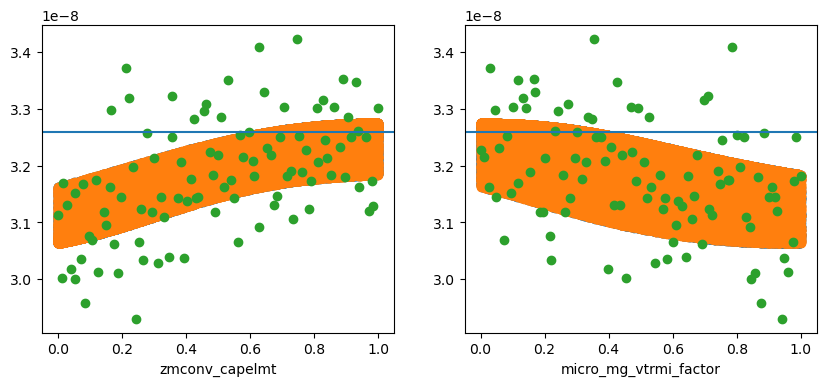

In [40]:
test_case.visualize_check('PRECT_zonal_-65to-55')

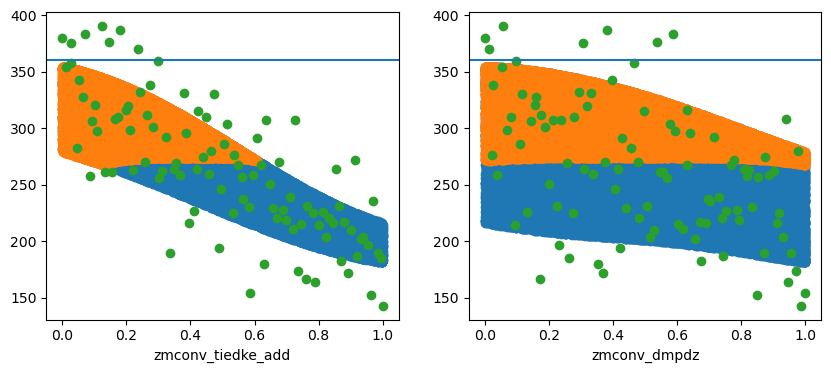

In [25]:
test_case.visualize_check('filter_precip099')

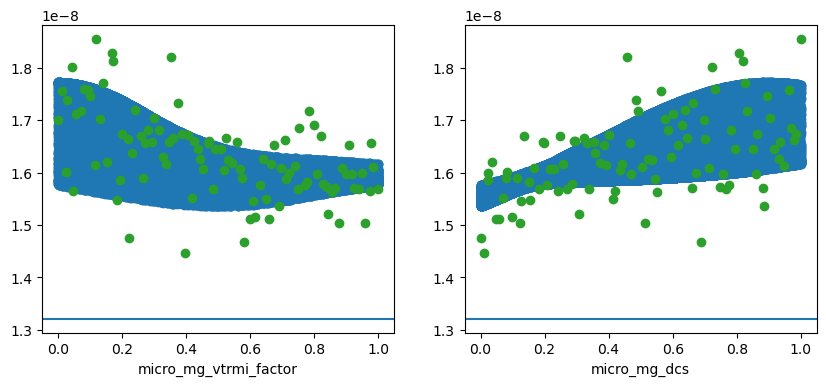

In [27]:
test_case.visualize_check('PRECT_zonal_-75to-65')

In [38]:
test_case.data_gcm.para_norm.corrwith(test_case.data_gcm.ppe_pd.filter_precip099)

micro_mg_max_nicons          0.091395
micro_mg_vtrmi_factor        0.223790
micro_mg_iaccr_factor       -0.106254
micro_mg_berg_eff_factor     0.049791
micro_mg_accre_enhan_fact   -0.084341
micro_mg_homog_size          0.011959
micro_mg_dcs                -0.096614
clubb_c1                    -0.076079
clubb_C8                     0.088421
clubb_c11                    0.081021
clubb_c14                   -0.055549
clubb_c_K10                 -0.069058
clubb_gamma_coef             0.070774
clubb_wpxp_L_thresh         -0.039593
clubb_beta                  -0.099213
clubb_c2rt                   0.199931
zmconv_c0_lnd                0.021727
zmconv_c0_ocn                0.035140
zmconv_ke                    0.147796
zmconv_dmpdz                -0.483610
cldfrc_dp1                   0.144997
cldfrc_dp2                  -0.029809
zmconv_num_cin               0.152309
zmconv_tiedke_add           -0.771327
zmconv_capelmt               0.406185
seasalt_emis_scale           0.028884
dust_emis_fa

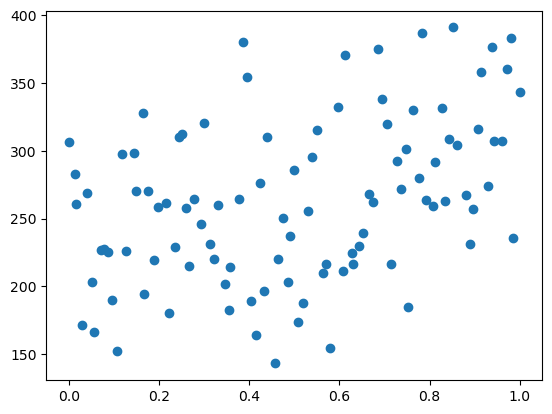

In [39]:
plt.scatter(test_case.data_gcm.para_norm.zmconv_capelmt, test_case.data_gcm.ppe_pd.filter_precip099)